# Retail Store Sales Analysis Using Pandas (Core)

*Part IV: Exploratory Data Analysis and Visualization*

Author: heleneInsights

Development Date

Start: 13-05-2026

Finish: 15-05-2026

---

## Introduction to the Project

In this fourth part of the project, we will apply advanced exploratory data analysis (EDA) and visualization techniques to better understand the retail store dataset. Using Python, Pandas, and Matplotlib, we will explore and visualize the data, identify patterns and trends, and prepare the dataset for deeper analysis.

---

## Dataset Description

In this project, we will use the Retail Sales Dataset (2023–2024) available on Kaggle. This dataset contains detailed records of daily sales transactions from a retail store, including information about products, quantities sold, pricing, and dates.

The dataset can be downloaded from Kaggle:

https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset

---

## Data Dictionary

The following table describes the variables included in the retail sales dataset used throughout this project.

| Column Name        | Data Type       | Description                                           | Example                             |
| ------------------ | --------------- | ----------------------------------------------------- | ----------------------------------- |
| `transaction_id`   | Integer         | Unique identifier for each sales transaction          | `1`                                 |
| `date`             | Date            | Date when the transaction occurred                    | `2023-11-24`                        |
| `customer_id`      | String          | Unique identifier assigned to each customer           | `CUST001`                           |
| `gender`           | Categorical     | Gender of the customer                                | `Male`, `Female`                    |
| `age`              | Integer         | Age of the customer                                   | `34`                                |
| `product_category` | Categorical     | Category of the purchased product                     | `Beauty`, `Clothing`, `Electronics` |
| `quantity`         | Integer         | Number of units purchased in the transaction          | `3`                                 |
| `price_per_unit`   | Float / Integer | Price of a single product unit                        | `50`                                |
| `total_amount`     | Float / Integer | Total transaction value (`quantity × price_per_unit`) | `150`                               |

---

## Setup

### Configuration and Imports

In [55]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Availability and Path Setup

In [56]:
data_dir = Path("../data")

# List available files (for verification)
available_files = list(data_dir.iterdir())
print("Available files:", available_files)

Available files: [WindowsPath('../data/retail_sales_dataset.csv')]


In [57]:
file_name = "retail_sales_dataset.csv"
dataset_path = data_dir / file_name

# Validate dataset existence
if not dataset_path.exists():
    raise FileNotFoundError(f"{file_name} not found in {data_dir}")

print("Dataset found at:", dataset_path)

Dataset found at: ..\data\retail_sales_dataset.csv


### Data Loading

The dataset is loaded into Pandas DataFrames from the CSV file.

In [58]:
df = pd.read_csv(dataset_path)

The first 10 rows are displayed to obtain an initial overview of the dataset structure, columns, and sample values.

In [59]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


This initial inspection helps verify that the dataset was loaded correctly and provides a quick understanding of the available information.

### Verify Structure

In [60]:
print(f"{file_name}")
print(f"Shape: {df.shape}")
print(f"→ {df.shape[0]} rows, {df.shape[1]} columns\n")

retail_sales_dataset.csv
Shape: (1000, 9)
→ 1000 rows, 9 columns



### First and Last Records

The first and last rows of the dataset were reviewed to verify the consistency and structure of the data after loading.

In [61]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [62]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


---

## Exploratory Data Analysis

### Dataset Overview

The dataset contains 1,000 rows and 9 columns with transactional and customer-related information, including purchase details, customer demographics, and pricing data.

The initial inspection of the dataset provides insights into:

- the total number of rows and columns,
- column names,
- data types,
- non-null values,
- and overall dataset structure.

According to the output of df.info(), all columns contain complete data with no missing values detected. However, the Date column is currently stored as a string (str) rather than a proper datetime format. This will be addressed during the data cleaning and preprocessing stage to ensure accurate date-based analysis.

The dataset consists of:

5 integer (int64) columns
4 string (str) columns

Additionally, the dataset uses approximately 70.4 KB of memory.

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


### Summary Statistics

The summary statistics provide an overview of the numerical variables in the dataset, including measures such as the mean, standard deviation, minimum, maximum, and quartile values.

Key observations from the analysis include:

- The average customer age is approximately 41 years.
- Customers purchase an average quantity of 2.5 products per transaction.
- The average price per unit is around 180, while the average total transaction amount is 456.
- Customer ages range from 18 to 64 years.
- The maximum transaction amount recorded is 2000.

These statistics help identify the general distribution of the data and provide useful insights before performing further analysis or visualization.

In [64]:
df.describe().round(2)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.00,1000.0
mean,500.50,41.39,2.51,179.89,456.0
std,288.82,13.68,1.13,189.68,560.0
min,1.00,18.00,1.00,25.00,25.0
25%,250.75,29.00,1.00,30.00,60.0
50%,500.50,42.00,3.00,50.00,135.0
75%,750.25,53.00,4.00,300.00,900.0
max,1000.00,64.00,4.00,500.00,2000.0


### Missing Values

No missing values were detected in the dataset, which simplifies the data cleaning process and ensures that all records contain complete information.

In [65]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Duplicate Records

`df.duplicated().sum()` was used to check for exact duplicate rows in the dataset.

The result shows that there are 0 duplicated records, meaning each row represents a unique observation. This indicates that the dataset does not contain repeated entries and no duplicate removal was needed.

In [66]:
n_duplicated = df.duplicated().sum()
print(f"Exact duplicated rows before cleaning: {n_duplicated}")

Exact duplicated rows before cleaning: 0


### Distribution Analysis

#### Categorical Value Consistency

This analysis examines the distribution and frequency of values across all dataset columns to identify patterns, inconsistencies, and potential data quality issues.

Key findings include:

- Both `Transaction ID` and `Customer ID` contain unique values for each record, indicating there are no duplicated transactions or customer identifiers.
- The `Gender` distribution is balanced, with 51% Female and 49% Male customers.
- Customer ages are relatively well distributed between 18 and 64 years, with no unusual concentration or invalid values detected.
- The `Product Category` column shows that:
    - **Clothing** is the most common category (35.1%),
    - followed by **Electronics** (34.2%),
    - and **Beauty** (30.7%).
- Product quantities are evenly distributed between 1 and 4 units per transaction.
- The `Price per Unit` values are limited to a small set of predefined prices, suggesting standardized pricing levels.
- The `Total Amount` column shows recurring transaction totals, which is expected due to combinations of quantity and unit price.

Overall, the dataset appears consistent and well-structured, with no obvious anomalies or invalid categorical values identified during this stage of the analysis.

In [67]:
for col in df.columns:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"{'='*40}")

    summary = (
        df[col]
        .value_counts(dropna=False)
        .reset_index()
    )

    summary.columns = [col, 'Count']

    summary['Percentage'] = (
        summary['Count'] / len(df) * 100
    ).round(2)

    print(summary)


Column: Transaction ID
     Transaction ID  Count  Percentage
0                 1      1         0.1
1                 2      1         0.1
2                 3      1         0.1
3                 4      1         0.1
4                 5      1         0.1
..              ...    ...         ...
995             996      1         0.1
996             997      1         0.1
997             998      1         0.1
998             999      1         0.1
999            1000      1         0.1

[1000 rows x 3 columns]

Column: Date
           Date  Count  Percentage
0    2023-05-16     11         1.1
1    2023-07-14     10         1.0
2    2023-05-23      9         0.9
3    2023-08-05      8         0.8
4    2023-02-05      8         0.8
..          ...    ...         ...
340  2023-03-02      1         0.1
341  2023-08-02      1         0.1
342  2023-04-17      1         0.1
343  2023-03-30      1         0.1
344  2023-05-28      1         0.1

[345 rows x 3 columns]

Column: Customer ID
    

#### Outlier Detection

Boxplots were used to visually inspect the numerical variables for potential outliers and unusual data distributions.

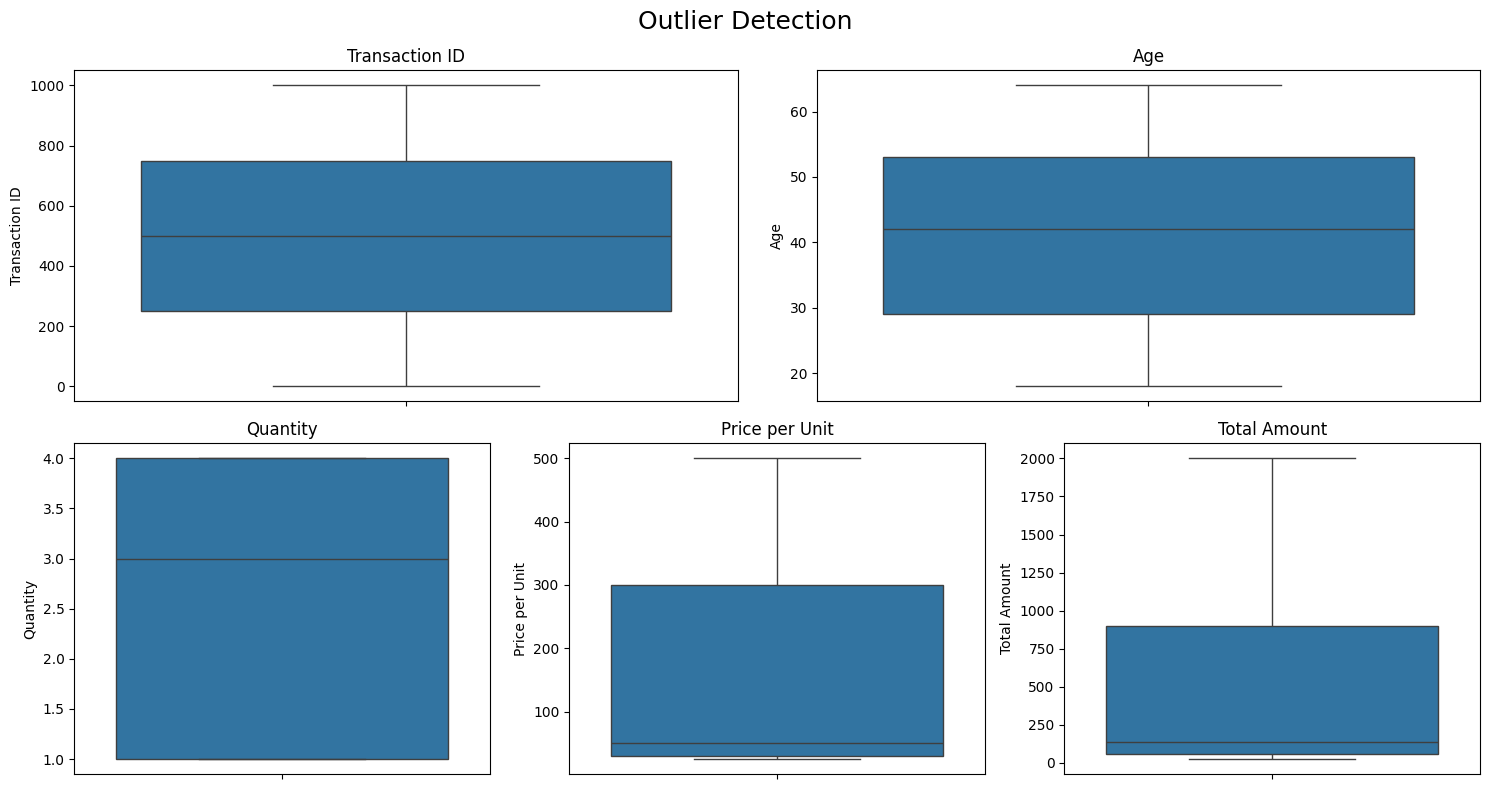

In [68]:
# Numerical columns
num_cols = [
    'Transaction ID',
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

# Create figure
fig = plt.figure(figsize=(15, 8))

# Global title
fig.suptitle('Outlier Detection', fontsize=18)

# Create custom grid
gs = fig.add_gridspec(2, 6)

# First row (2 plots)
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# Second row (3 plots)
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes = [ax1, ax2, ax3, ax4, ax5]

# Plot boxplots
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

The analysis indicates that:

- `Age` values are evenly distributed within the expected range, with no significant outliers detected.
- `Quantity` shows a very limited range (1 to 4), which explains the absence of extreme values.
- `Price` per Unit and Total Amount display wider distributions due to the variation in product prices and transaction sizes; however, the values remain consistent with the business context of the dataset.
- `Transaction ID` does not present meaningful outliers since it represents a sequential identifier rather than a measurable variable.

Overall, the boxplots do not reveal critical anomalies or suspicious extreme values, suggesting that the numerical data is relatively clean and suitable for further analysis.

#### Histograms

Histograms were used to visualize the distribution of the numerical variables in the dataset and better understand their frequency patterns, spread, and concentration of values.

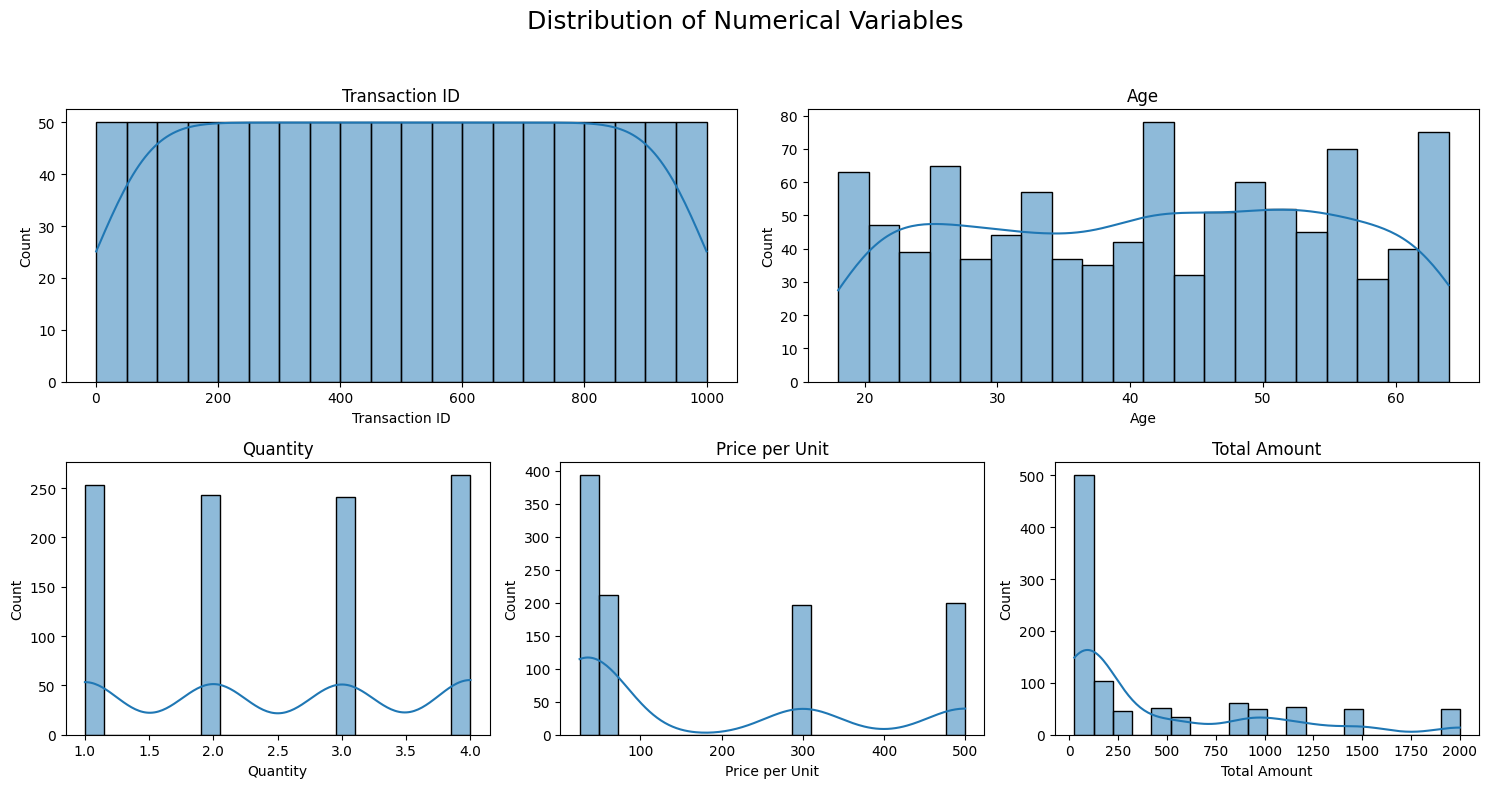

In [69]:
# Numerical columns
num_cols = [
    'Transaction ID',
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

# Create figure
fig = plt.figure(figsize=(15, 8))

# Global title
fig.suptitle('Distribution of Numerical Variables', fontsize=18)

# Create custom grid
gs = fig.add_gridspec(2, 6)

# First row
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# Second row
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes = [ax1, ax2, ax3, ax4, ax5]

# Plot histograms
for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

Key observations from the histograms include:

- `Transaction ID` shows a uniform distribution because the identifiers are sequentially assigned.
- `Age` appears relatively evenly distributed across the observed age range, without strong skewness.
- `Quantity` contains only a few discrete values (1 to 4), resulting in clearly separated bars.
- `Price per Unit` presents grouped price levels, indicating standardized product pricing.
- `Total Amount` is right-skewed, with a higher concentration of lower transaction amounts and fewer high-value purchases.

Additionally, the KDE (Kernel Density Estimation) curves help visualize the overall shape and density of each distribution, making it easier to identify trends and potential skewness in the data.


#### Combined View

This combined visualization was created to analyze the distribution and potential outliers of the two most business-relevant sales variables.

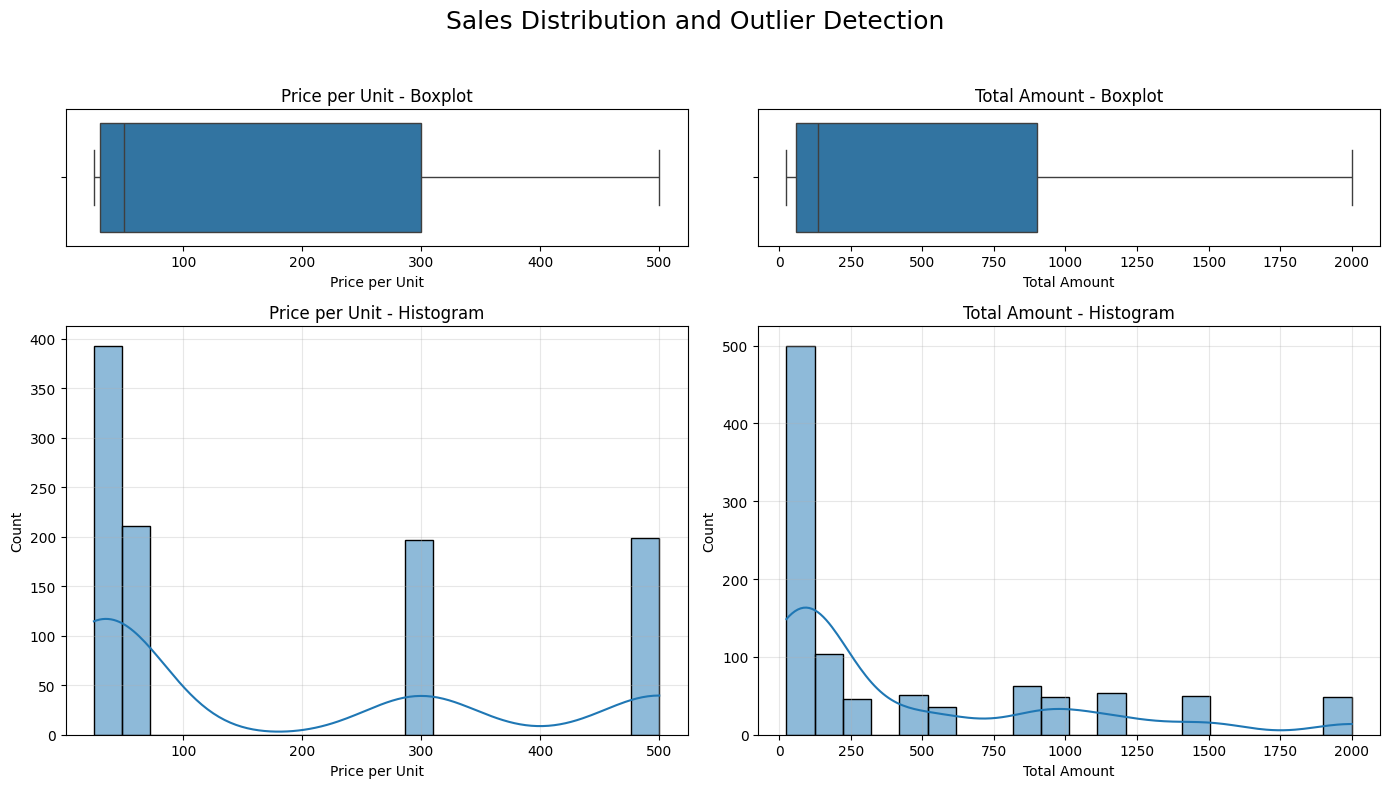

In [70]:
# Variables to analyze
cols = ['Price per Unit', 'Total Amount']

# Create figure
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 8),
    gridspec_kw={'height_ratios': [1, 3]}
)

# Global title
fig.suptitle(
    'Sales Distribution and Outlier Detection',
    fontsize=18
)

# Loop through variables
for i, col in enumerate(cols):

    # Boxplot (top)
    sns.boxplot(
        data=df_clean,
        x=col,
        ax=axes[0, i]
    )

    axes[0, i].set_title(f'{col} - Boxplot')

    # Histogram (bottom)
    sns.histplot(
        data=df_clean,
        x=col,
        bins=20,
        kde=True,
        ax=axes[1, i]
    )

    axes[1, i].set_title(f'{col} - Histogram')

    # Subtle grid
    axes[1, i].grid(alpha=0.3)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

This visualization combines boxplots and histograms to analyze the distribution of key sales-related variables and identify potential outliers.

The boxplots provide a summary of the data spread, median values, and possible extreme observations, while the histograms show the frequency distribution and overall shape of the data.

Key observations include:

- Price per Unit presents several predefined pricing levels, resulting in grouped distribution patterns rather than a continuous spread.
- Total Amount shows a right-skewed distribution, where lower transaction amounts occur more frequently than high-value purchases.
- No critical or suspicious outliers were identified, as the observed high values remain consistent with expected transaction behavior.

Overall, the combined visualization offers a clearer understanding of sales patterns, variability, and potential anomalies within the dataset.

### Transaction Validation

This validation confirms that the Total Amount column was calculated correctly for all transactions.

$\text{Total Amount} = \text{Quantity} \times \text{Price per Unit}$

**Observation**

All transaction totals were consistent with the quantity purchased and the corresponding unit price, indicating good data integrity.

In [71]:
(df['Quantity'] * df['Price per Unit'] == df['Total Amount']).all()

np.True_

---

## Data Cleaning

During the initial assessment, it was identified that the `Date` column was stored as a string (`str`) instead of a datetime type.

To correct this issue, the column was converted to `datetime` format using `pd.to_datetime()`.

In [72]:
df_clean = df.copy()

In [73]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
df_clean["Date"].isna().sum()

np.int64(0)

The parameter `errors="coerce"` converts invalid date values into `NaT` (Not a Time), which makes problematic records easier to detect and handle during the cleaning process.

**Observation**

After the conversion, no invalid date values were detected, indicating that the Date column was successfully transformed into `datetime` format.

### Invalid Datetime Check

In [74]:
df_clean[df_clean["Date"].isna()]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount


This check was performed to identify rows with invalid or missing datetime values after the conversion process.

Since no rows were returned, no invalid date values were found in the dataset.

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [76]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


The comparison between the original and cleaned DataFrames confirms that the Date column was successfully converted from `str` to `datetime64[ns]`.

**Observation**

The conversion improves the dataset structure and enables future time-based analysis such as monthly grouping, trend analysis, and date filtering.

### Updated Descriptive Statistics

In [77]:
df_clean.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


After the data cleaning process, descriptive statistics were reviewed again to verify the consistency of the numerical columns and ensure that the dataset remained valid after the transformations.

### Cleaned Dataset Preview

In [78]:
df_clean.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


The cleaned dataset was reviewed to verify that the transformations were applied correctly and that the overall structure remained consistent.

**Insight**

Converting columns to appropriate data types improves data consistency and enables more efficient filtering, grouping, and time-based analysis operations.

It also prepares the dataset for visualization and future stages such as predictive modeling.

---

## Data Transformation

### Create New Columns

New columns were created from existing variables in order to generate more useful metrics and improve the analytical capabilities of the dataset.

These transformations help simplify comparisons between customers, spending behavior, and product pricing levels.

#### Normalize Sales

The Total Amount column was normalized using Min-Max normalization to scale values between 0 and 1.

$x' = \frac{x − x_{min}}{x_{max} - x_{min}} $

In [79]:
df_clean['Total Amount Normalized'] = (
    (df_clean['Total Amount'] - df_clean['Total Amount'].min()) /
    (df_clean['Total Amount'].max() - df_clean['Total Amount'].min())
)

In [80]:
df_clean[[
    'Transaction ID',
    'Total Amount',
    'Total Amount Normalized'
]].head()

,Transaction ID,Total Amount,Total Amount Normalized
0,1,150,0.063291
1,2,1000,0.493671
2,3,30,0.002532
3,4,500,0.240506
4,5,100,0.037975


**Insight**

Normalization makes values easier to compare by placing all transaction amounts within the same scale. This technique is especially useful for future machine learning and predictive modeling tasks.

#### Age Group

Customers were divided into age ranges to simplify demographic analysis.

In [81]:
df_clean['Age Group'] = pd.cut(
    df_clean['Age'],
    bins = [0, 25, 35, 50, 100],
    labels = ['Young adult', 'Adult', 'Middle age', 'Senior']
)

In [82]:
df_clean[[
    'Age',
    'Age Group',
    'Product Category',
    'Total Amount'
]].head()

,Age,Age Group,Product Category,Total Amount
0,34,Adult,Beauty,150
1,26,Adult,Clothing,1000
2,50,Middle age,Electronics,30
3,37,Middle age,Clothing,500
4,30,Adult,Beauty,100


**Insight**

Grouping customers by age makes it easier to identify spending patterns and purchasing behavior across different demographic groups.

#### Spending Category

Transactions were classified into spending levels based on the `Total Amount` column.

In [83]:
df_clean['Spending Category'] = pd.cut(
    df_clean['Total Amount'],
    bins = [0, 100, 500, df_clean['Total Amount'].max()],
    labels = ['Low', 'Medium', 'High'],
    include_lowest = True
)

In [84]:
df_clean[[
    'Total Amount',
    'Spending Category'
]].head()

,Total Amount,Spending Category
0,150,Medium
1,1000,High
2,30,Low
3,500,Medium
4,100,Low


**Insight**

This categorization helps distinguish low, medium, and high spending transactions, allowing easier comparison of customer purchasing behavior.

#### Price Tier

Products were grouped into pricing levels according to their unit price.

In [85]:
df_clean['Price Tier'] = pd.cut(
    df_clean['Price per Unit'],
    bins = [0, 50, 200, df_clean['Price per Unit'].max()],
    labels = ['Budget', 'Standard', 'Premium'],
    include_lowest = True
)

In [86]:
df_clean[[
    'Price per Unit',
    'Price Tier'
]].head(10)

,Price per Unit,Price Tier
0,50,Budget
1,500,Premium
2,30,Budget
3,500,Premium
4,50,Budget
5,30,Budget
6,25,Budget
7,25,Budget
8,300,Premium
9,50,Budget


**Insight**

Price segmentation helps identify the distribution of low-cost, mid-range, and premium products within the dataset.

It also supports future comparisons between pricing levels and customer spending behavior.

---

## Sales Trends

### Monthly Sales Trend

The monthly sales trend analysis was performed to evaluate how total sales evolved over time and identify potential seasonal patterns or fluctuations in revenue.

The line chart shows that sales remained relatively stable throughout most months, with some noticeable peaks and declines. Higher sales volumes were observed during specific periods, suggesting possible seasonal demand or stronger customer activity during those months.

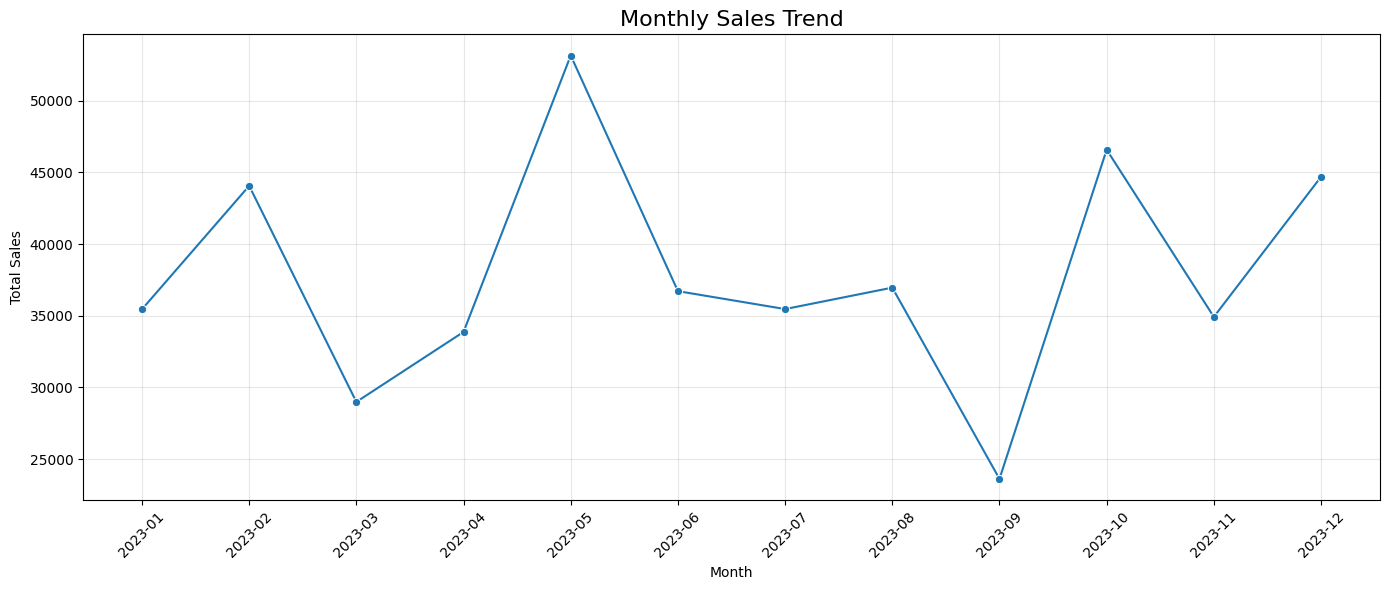

In [87]:
# Monthly sales aggregation
monthly_sales = (
    df_clean
    .groupby(df_clean['Date'].dt.to_period('M'))['Total Amount']
    .sum()
    .reset_index()
)

# Remove incomplete month
monthly_sales = monthly_sales[
    monthly_sales['Date'] != '2024-01'
]

# Convert period to string
monthly_sales['Date'] = monthly_sales['Date'].astype(str)

# Create figure
plt.figure(figsize=(14, 6))

# Line plot
sns.lineplot(
    data=monthly_sales,
    x='Date',
    y='Total Amount',
    marker='o'
)

# Titles and labels
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales')

# Rotate labels
plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Key observations include:

- Sales reached their highest level around **May 2023**.
- Additional strong sales periods can be observed in **October** and **December**.
- Lower sales activity occurred during **September 2023**.

Overall, the visualization provides a clear overview of revenue behavior across time and helps support business decisions related to marketing strategies, inventory planning, and seasonal sales analysis.

### Monthly Sales Trend by Category

This analysis explores how sales evolved over time across different product categories, allowing a more detailed understanding of category-level performance throughout the year.

The visualization shows monthly sales trends for the three product categories: Beauty, Clothing, and Electronics.

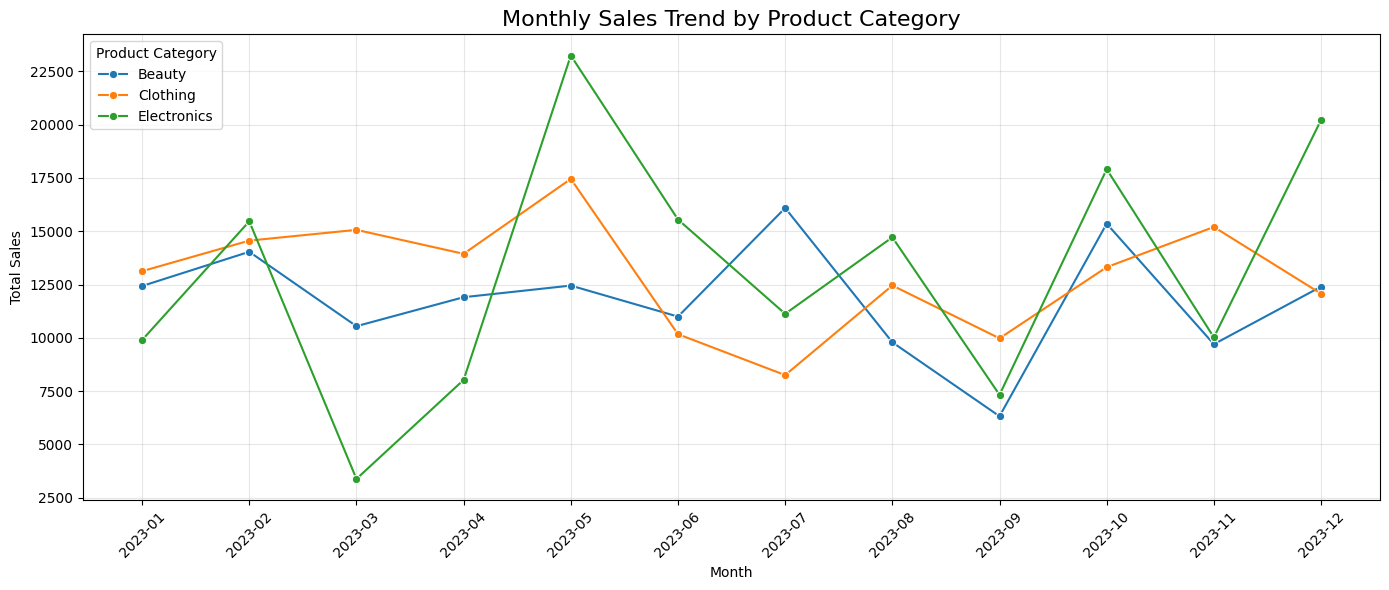

In [88]:
# Monthly sales by category
monthly_category_sales = (
    df_clean
    .groupby(
        [
            df_clean['Date'].dt.to_period('M'),
            'Product Category'
        ]
    )['Total Amount']
    .sum()
    .reset_index()
)

# Remove incomplete month
monthly_category_sales = monthly_category_sales[
    monthly_category_sales['Date'] != '2024-01'
]

# Convert period to string
monthly_category_sales['Date'] = (
    monthly_category_sales['Date']
    .astype(str)
)

# Create figure
plt.figure(figsize=(14, 6))

# Line plot
sns.lineplot(
    data=monthly_category_sales,
    x='Date',
    y='Total Amount',
    hue='Product Category',
    marker='o'
)

# Titles and labels
plt.title(
    'Monthly Sales Trend by Product Category',
    fontsize=16
)

plt.xlabel('Month')
plt.ylabel('Total Sales')

# Rotate labels
plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Key observations include:

- Electronics presents the highest volatility, with significant sales peaks in May, October, and December.
- Clothing maintains a relatively stable performance across most months, showing more consistent sales behavior.
- Beauty demonstrates moderate fluctuations, with stronger performance observed around July and October.
- All categories experienced lower sales activity during September compared to surrounding months.

This chart provides valuable business insights by highlighting seasonal demand patterns and category-specific performance trends. Such information can support decisions related to inventory management, promotional campaigns, and sales forecasting.

## Relations Among Variables

### Price per Unit vs Total Amount

The scatter plot shows the relationship between **Price per Unit** and **Total Amount** for different product categories.

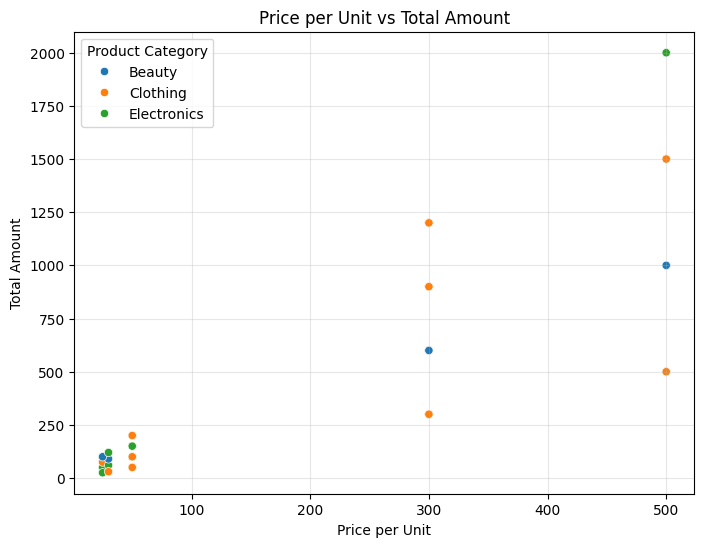

In [89]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x='Price per Unit',
    y='Total Amount',
    hue='Product Category'
)

plt.title('Price per Unit vs Total Amount')

plt.grid(alpha=0.3)

plt.show()

**Insights**

- Higher prices generally lead to higher total amounts.
- **Electronics** products have the highest total amounts.
- **Clothing** shows more variation in total amount at the same price level.
- **Beauty** products mostly have lower prices and lower total amounts.

**Conclusion**

The chart suggests that products with higher unit prices usually generate more sales value, especially in the Electronics category.

### Quantity vs Total Amount

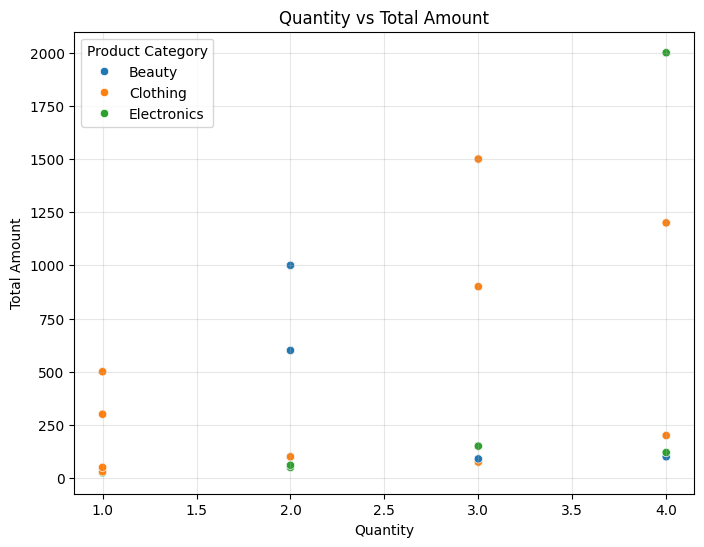

In [90]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x='Quantity',
    y='Total Amount',
    hue='Product Category'
)

plt.title('Quantity vs Total Amount')

plt.grid(alpha=0.3)

plt.show()

The chart shows a strong positive relationship between quantity and total amount spent. As customers buy more items, the total cost increases consistently, which is expected.

The data points follow a mostly straight-line pattern, suggesting that prices remain fairly consistent across purchases. There are also no major outliers, as most transactions stay close to the overall trend.

Overall, the plot indicates a simple and predictable pattern: higher quantities lead to higher total spending in a largely linear way.

### Age vs Total Amount

The chart shows that spending generally increases with age, although spending levels vary within each age group.

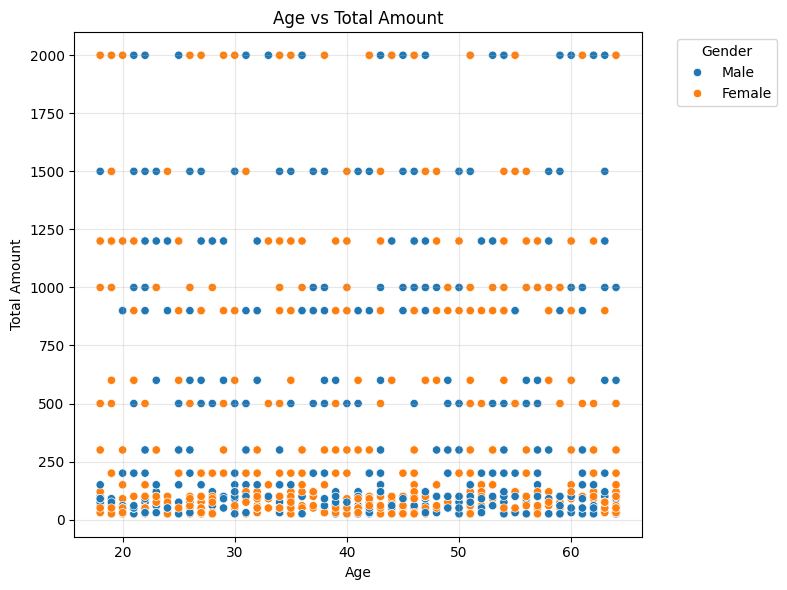

In [91]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x='Age',
    y='Total Amount',
    hue='Gender'
)

plt.title('Age vs Total Amount')

# Move legend outside
plt.legend(
    title='Gender',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

-  Female customers show a steady spending pattern, with spending slightly increasing as they get older.
-  Male customers also tend to spend more with age, and some older males appear to spend more than females.

Most purchases are in the low to medium spending range, but a few older customers from both genders are high spenders. Overall, both genders follow a similar trend of higher spending with age.

---

## Final Summary

This exploratory data analysis provided a comprehensive overview of the retail sales dataset, including its structure, data quality, variable distributions, and sales behavior patterns.

During the analysis:

- The dataset structure and data types were inspected and validated.
- Missing values and data consistency were evaluated.
- The `Date` column was converted to datetime format to support time-based analysis.
- Additional features such as `Age Group`, `Spending Category`, `Price Tier`, and normalized sales values were created to facilitate visualization and interpretation.
- Summary statistics helped identify general trends and variable ranges.
- Histograms and boxplots were used to analyze data distributions and detect potential outliers.
- Monthly sales trends revealed variations in revenue across time and highlighted seasonal behavior patterns.
- Category-level sales analysis provided deeper insights into the performance of Beauty, Clothing, and Electronics products.
- Scatterplots and relationship analysis helped explore interactions between customer demographics, pricing, quantities, and transaction values.

Overall, the dataset appears clean, consistent, and well-structured for further analysis. The visualizations and statistical exploration provided valuable business insights that can support decision-making related to sales performance, customer behavior, inventory planning, and marketing strategies.

---

### Limitations

Due to time constraints, some aspects of the analysis may have been overlooked or could be explored in greater depth. However, every effort was made to perform a thorough exploratory analysis and provide meaningful insights based on the available data and time provided.

---

### Acknowledgements

To my teachers, for reminding me to look for outliers, for the plot examples provided during Class 15, and for the support offered during the assistantship sessions.

To the AI assistants, for helping me improve the documentation, refine the visualizations, and correct and enhance the plots throughout the project.